In [ ]:
# getting the LibraryDesigner is a little tricky, you need to get it in the correct location (or append the location to the path)
# and you also need to compile the Cpython extension for your particular OS.  Instructions are in the LibraryDesigner.py file

In [2]:
import os
import sys
import glob
sys.path.append('/home/bbintu/LibraryDesign3/')
import LibraryDesigner as ld
import LibraryTools as lt
from seqint import seq2Int, seq2Int_rc
import pickle
from tqdm.notebook import tqdm
# some other packages may required
import Bio #use pip install biopython
from scipy.spatial import distance

import numpy as np
from pyensembl import EnsemblRelease

import logging
logger = logging.getLogger("pyensembl")
logger.setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# this notebook uses several very large files, all of them can be downloaded at:\
# cmm200-136.ucsd.edu/data

In [28]:
# this jsut tests if you have py ensembl working
data = EnsemblRelease(release=104,species='mus_musculus')
data.genes_by_name('Acr')

[Gene(gene_id='ENSMUSG00000022622', gene_name='Acr', biotype='protein_coding', contig='15', start=89452529, end=89458788, strand='+', genome='GRCm39')]

# these are all functions to get proper ensembl gene names from a set of informal names

In [3]:
def fuzzy_match(query, subjects):
    from thefuzz import fuzz
    query = query.lower()
    best = None
    dist = 0
    for subject in subjects:
        d = fuzz.ratio(query, subject.lower())
        if d > dist:
            dist = d
            best = subject
    return best

def levenshtein_fuzzy_match(query, subjects):
    import Levenshtein
    query = query.lower()
    best = []
    dist = float('inf')
    for subject in subjects:
        d = Levenshtein.distance(query, subject.lower())  
        if d < dist:
            dist = d
            best = [subject]
        elif d == dist:
            best.append(subject)
    return best

def get_official_name(bad_name):
    import urllib.request
    fp = urllib.request.urlopen("https://www.ncbi.nlm.nih.gov/gene/?term="+bad_name+r'%5Bgene%5D+Mus+musculus')
    mystr = fp.read().decode("utf8")
    fp.close()
    tag = '    <title>'
    final_name = [ln.split(tag)[-1].split(' ')[0] for ln in mystr.split('\n') if tag in ln][0]
    return final_name

def get_alternative_names(bad_name, taxa=''):
    import urllib.request
    fp = urllib.request.urlopen("https://www.ncbi.nlm.nih.gov/gene/?term="+bad_name+'%5Bgene%5D+'+ taxa.replace(' ','+') )
    mystr = fp.read().decode("utf8")
    fp.close()
    tag = '    <title>'
    final_name = [ln.split(tag)[-1].split(' ')[0] for ln in mystr.split('\n') if tag in ln][0]
    try:
        alt_names = mystr.split("Also known as")[-1].split('<dd>')[1].split('</dd>')[0].split('; ')
    except:
        alt_names = []
    alt_names=[final_name]+alt_names
    return alt_names

In [4]:
def get_ncbi_sequence(id_='NM_001077363.3'):
    #Entrez.email = "bbintu@ucsd.edu"
    from Bio import Entrez
    handle = Entrez.efetch(db="nucleotide", id=id_, retmode="xml")
    records = Entrez.read(handle)
    name = records[0]["GBSeq_primary-accession"]+" "+records[0]["GBSeq_definition"]
    seq = ''
    if "GBSeq_sequence" in records[0]:
        seq = records[0]["GBSeq_sequence"]
    return name,seq
def get_transcripts(gene,retmax=100):
    from tqdm.notebook import tqdm
    import time
    from Bio import Entrez
    handle = Entrez.esearch(db="nucleotide", retmax=retmax, term=gene+'[GENE] AND "Mus musculus"[Primary Organism] AND (biomol_mrna[PROP] AND refseq[filter])')
    record = Entrez.read(handle)
    handle.close()
    names = []
    seqs = []
    for id_ in tqdm(record['IdList']):
        name,seq = get_ncbi_sequence(id_=id_)
        if gene in name:
            names.append(name)
            seqs.append(seq)
        time.sleep(0.5)
    return names,seqs
def get_transcripts_v2(gene,retmax=100):
    from tqdm.notebook import tqdm
    import time
    from Bio import Entrez
    Entrez.email = 'bbintu@ucsd.edu'
    handle = Entrez.esearch(db="nucleotide", retmax=retmax, term=gene+'[GENE] AND "Mus musculus"[Primary Organism] AND (refseq[filter])')
    record = Entrez.read(handle)
    handle.close()
    names = []
    seqs = []
    for id_ in tqdm(record['IdList']):
        #print(id_)
        name,seq = get_ncbi_sequence(id_=id_)
        if 'NC_' not in name:
            names.append(name)
            seqs.append(seq)
        time.sleep(0.5)
    return names,seqs

In [5]:
def get_ints(sq,word = 12,verbose=True):
    ints = []
    if len(sq)>=word:
        sq_ = sq.encode()# encode to bytes
        iters = tqdm(range(len(sq_)-word+1)) if verbose else range(len(sq_)-word+1)
        for i in iters:
            ints.append(ld.seq2Int(sq_[i:i+word]))
    return ints

def result_file(in_files,word=12,top_hits=500,tr_folder = '/data/mm10_transcriptome'):
    """
    writes results of homology to file replacing each filename .fasta -> _isoResults.results
    This file contains names of sequences with high homology, pvalue assuming Bernoulli, 
    fraction of orginal transcript homology, fraction of target trancript homology
    """
    if True:#try:
        fl_ints = os.path.join(tr_folder, 'mouse_GRCm39_genesUnspliced12bp.pkl')
        ints_tr  = pickle.load(open(fl_ints,'rb'))
        lens_tr = [len(int_) for int_ in ints_tr]
        names_tr = np.load(os.path.join(tr_folder,'names_transcriptome.npy'))
        for fl in tqdm(in_files):
            fl_ = fl.replace('.fasta','_isoResults.results')
            if not os.path.exists(fl_):
                sq_T = lt.fastaread(fl)[-1][0]
                word=12
                lens_ = lens_tr
                ints__ = ints_tr
                names__ = names_tr
                intT = np.unique(get_ints(sq_T,word = word,verbose=False)[::word])
                CT = np.array([np.in1d(intT,int_,assume_unique=True) for int_ in tqdm(ints__)])
                logprand = np.log(np.sum(CT[:,:]))-np.log(np.sum(lens_))-np.log(CT.shape[-1])
                from scipy.stats import binomtest
                pvalues = []
                for itr in np.arange(len(CT)):
                    pvalue=1
                    if lens_[itr]>0:
                        try:
                            result = binomtest(np.sum(CT[itr]), n=lens_[itr], p=np.exp(logprand+np.log(CT.shape[-1])), alternative='greater')
                            pvalue = result.pvalue
                        except:
                            pass
                    pvalues.append(pvalue)
                ibest = np.argsort(np.log(pvalues))[:top_hits]
                result = [(names__[ib],pvalues[ib],np.mean(CT[ib]),np.sum(CT[ib])/lens_[ib]*word) for ib in ibest]
                text = '\n'.join([','.join([str(e) for e in ln]) for ln in result])

                fid = open(fl_,'w')
                fid.write(text)
                fid.close()
    else:#except:
        print('Failed')
        pass

In [6]:
def test_overlap(gn1,gn2):
    chr_1,start_1,end_1,sense_1 = names_tr[names_tr_.index(gn1)].split('|')[-4:]
    start_1,end_1 = int(start_1),int(end_1)
    chr_2,start_2,end_2,sense_2 = names_tr[names_tr_.index(gn2)].split('|')[-4:]
    start_2,end_2 = int(start_2),int(end_2)
    overlap = False
    if chr_1==chr_2:
        if ((start_1<end_2)&(start_2<end_1)):
            overlap=True
    return overlap

In [24]:
class geneInfo(): # modified class to accept a list as biotype
    def __init__(self,transcript_file, biotype=None):#protein_coding
        self.transcript_file = transcript_file
        
        self.names,self.seqs = lt.fastaread(transcript_file)
        self.data = EnsemblRelease(release=104,species='mus_musculus')
        self.biotype=biotype
    def load(self,gn_name):
        self.gn_name = gn_name
        try:
            if self.gn_name.startswith('ENS'):
                self.gns = self.gene = self.data.gene_by_id(self.gn_name)
            else:
                self.gns = self.data.genes_by_name(self.gn_name)
                self.gene = self.gns[0]
            if self.biotype is None:
                if np.any(['protein_coding' in t.biotype for t in self.gene.transcripts if (t.sequence is not None)]):
                    self.biotype = 'protein_coding'

            len_seqs = [len(t.sequence) for t in self.gene.transcripts if (t.sequence is not None) if (t.biotype in self.biotype)]

            #self.gene_transcripts = [t for t in self.gene.transcripts if (t.sequence is not None) if (self.biotype in t.biotype)]
            self.gene_transcripts = [t for t in self.gene.transcripts if (t.sequence is not None) if (t.biotype in self.biotype)]
        except:
            len_seqs=[]
        self.exon_sequence =''
        self.intron_sequence =''
        self.full_sq = ''
        if len(len_seqs):
            # select longest transcript
            self.transcript = self.gene_transcripts[np.argmax(len_seqs)]
            self.full_sq = [sq for nm,sq in zip(self.names,self.seqs) if self.gene.id in nm][0]
            self.strand = int(self.gene.strand=='-')
            self.exon_interv = np.array(self.transcript.exon_intervals)-self.gene.start if self.strand==0 else self.gene.end-np.array(self.transcript.exon_intervals)[:,::-1]

            bp_exon = [e_ for st,ed in self.exon_interv for e_ in np.arange(st,ed)]
            bp_intron = np.setdiff1d(np.arange(0,self.gene.end-self.gene.start),bp_exon)
            self.intron_interv = []
            if len(bp_intron):
                inz = np.where(np.diff(bp_intron)!=1)[0]
                self.intron_interv = np.array([[bp_intron[0]]+list(bp_intron[inz+1]),list(bp_intron[inz])+[bp_intron[-1]]]).T
            self.exon_sequence = self.transcript.sequence
            if len(self.intron_interv):
                self.intron_sequence = 'N'.join([self.full_sq[st:ed] for st,ed in self.intron_interv])
gene_info = geneInfo(transcript_file='/data/mm10_transcriptome/mouse_GRCm39_genesUnspliced.fasta', biotype=['protein_coding','lncRNA'])

In [25]:
# this just tests if you have the library designer code working
gene_info.load('Acr')
gene_info.exon_sequence

'GAGGTCACAGCTTGCAGGCCAGGTTAGGGCAGGAGTATGGTAGAGATGCTGCCAACTGTCGCTGTGCTGGTCTTGGCAGTGTCCGTGGTTGCCAAGGATAACACCACGTGTGATGGTCCCTGTGGGTTACGATTCAGGCAGAACTCACAAGCAGGTACCCGGATTGTCAGTGGGCAGAGTGCGCAGCTTGGGGCCTGGCCCTGGATGGTCAGCTTACAGATCTTCACGTCCCATAACAGCCGCAGGTACCACGCCTGTGGAGGCAGCCTCCTGAACTCCCACTGGGTGCTCACAGCTGCCCACTGCTTCGATAACAAAAAAAAAGTCTATGACTGGAGACTGGTTTTCGGAGCACAAGAAATCGAATATGGAAGAAACAAGCCAGTGAAAGAGCCCCAGCAGGAGAGATATGTGCAGAAGATTGTCATCCATGAGAAATACAACGTAGTGACGGAGGGAAATGACATTGCGCTCTTGAAGATCACTCCTCCTGTTACATGTGGGAACTTCATTGGACCCTGCTGTCTACCTCATTTTAAGGCGGGTCCTCCCCAAATACCCCACACCTGCTACGTGACTGGGTGGGGATACATAAAAGAGAAGGCCCCCAGGCCATCACCTGTCCTGATGGAAGCACGTGTGGACCTCATTGACCTCGACCTGTGTAACTCAACCCAGTGGTACAATGGGCGTGTCACATCGACTAATGTGTGTGCAGGGTATCCTGAAGGCAAGATTGACACCTGCCAGGGGGACAGTGGTGGGCCTCTCATGTGCAGAGACAACGTCGACAGCCCCTTTGTGGTCGTGGGGATCACGAGCTGGGGGGTAGGCTGTGCCCGTGCTAAGCGTCCCGGAGTCTACACAGCCACCTGGGACTACCTGGACTGGATTGCTTCCAAGATCGGCCCTAACGCCTTGCACTTGATTCAGCCAGCCACCCCTCATCCGCCGACTACCCGCCATCCGATGGTCTCTTTTCACCCTCCTTCTCTTCGC

### 0.0.1 Design probes for genes. Save fasta files with the sequences

In [12]:
# these were the names that were given to me, most match ensebl gene names, but some do not
genes = np.loadtxt("target_genes.txt", dtype=str)
genes

array(['Abat', 'Abhd12', 'Ache', 'Actg1', 'Actl6b', 'Acvr1b', 'Acvr1c',
       'Adam10', 'Adam12', 'Adam17', 'Adam23', 'Adam28', 'Adora2a', 'Agk',
       'Ahi1', 'Aif1', 'Ajap1', 'Akap8l', 'Akr1b3', 'Akt1', 'Akt2',
       'Akt3', 'Alg2', 'Ang', 'Angpt1', 'Angptl4', 'Ankrd34b', 'Ap2s1',
       'Apaf1', 'Apba1', 'Aplp1', 'Apoe', 'App', 'Areg', 'Arf3',
       'Arhgap26', 'Arhgef9', 'Ascl1', 'Atf3', 'Atf4', 'Atf6', 'Atg13',
       'Atg14', 'Atg2a', 'Atg2b', 'Atm', 'Atp1b1', 'Atp6v0c', 'Atp6v0d1',
       'Atp6v0e2', 'Atp6v1b2', 'Atp6v1d', 'Atp6v1f', 'Atp6v1g1', 'Atp9a',
       'Atxn10', 'Atxn2l', 'Axl', 'Bace1', 'Bace2', 'Bad', 'Bax',
       'Bcl2l1', 'Bdnf', 'Beclin1', 'Begain', 'Bex3', 'Bid', 'Bmi1',
       'Bmp2', 'Bmp6', 'Brinp2', 'Btbd3', 'C1qa', 'C1qb', 'C1qc',
       'C1qtnfl', 'C3', 'C3ar1', 'C5ar1', 'Cacna1a', 'Cacna1c', 'Cacnaic',
       'Cacna1d', 'Cacna1e', 'Cacna1f', 'Cacna1g', 'Cacna1s', 'Cacna2d2',
       'Cacnb3', 'Cadps2', 'Calb1', 'Calm1', 'Calm2', 'Calml5', 'Calml3',
    

In [10]:
# this goes through each of the names and gets the fasta sequences for those with proper names
save_folder_probes = 'probes'
bad_name = list()
for gene in genes:
    gene_info.load(gene)
    #gn = geneInfo_.gene.gene_name
    exon_len = len(gene_info.exon_sequence)
    intron_len = len(gene_info.intron_sequence)
    #print([gene,exon_len,intron_len], end='\t')
    if exon_len == 0:
        bad_name.append(gene)
    else:
        lt.fastawrite(save_folder_probes+os.sep+gene+'_exons.fasta',[gene+'_exons'],[gene_info.exon_sequence])
        if intron_len: #gene in genes_with_introns:
            lt.fastawrite(save_folder_probes+os.sep+gene+'_introns.fasta',[gene+'_introns'],[gene_info.intron_sequence])
            pass
print(*bad_name, sep='   ') 

Beclin1   C1qtnfl   Cacnaic   Calml5   Ccl16   Cd1d   Cd58   Cd59   Cxcl8   Nox2   Cd99   Gsk3   Icam3   Mmp1   Pen2   Rab11   Rab4   Rabaptin5   Rabex5   Raptor   Ccl13   Serpinb4   Slciial   Slc25a6   Slcgal   Rn-tre   Gm36327   Il32   S100a12   Slctaz   Tlr10   Tnfrsf10c   Calml6   Calml6


In [41]:
# this does fuzzy matching to help identify the correct ensembl name
gene_names = gene_info.data.gene_names()
for bad in bad_name:
    print(bad, levenshtein_fuzzy_match(bad, gene_names), get_official_name(bad), sep='\t', end='\t')
    alts = get_alternative_names(bad, 'Mus musculus')
    for alt in alts:
        if gene_info.load(alt) or gene_info.exon_sequence:
            print(alt, end='')
            break

    print('\t', end='')
    print(alts)

Beclin1	['Becn1', 'Erlin1', 'Nectin1']	No		['No']
C1qtnfl	['C1qtnf1', 'C1qtnf2', 'C1qtnf3', 'C1qtnf4', 'C1qtnf5', 'C1qtnf6', 'C1qtnf7', 'C1qtnf9']	No		['No']
Cacnaic	['Cacna1c']	No		['No']
Calml5	['Calm5', 'Calml3', 'Calml4']	No		['No']
Calml6	['Calml3', 'Calml4']	No		['No']
Ccl13	['Ccl1', 'Ccl11', 'Ccl12', 'Ccl17', 'Ccl19', 'Ccl3', 'Cxcl13']	No		['No']
Ccl16	['Ccl1', 'Ccl11', 'Ccl12', 'Ccl17', 'Ccl19', 'Ccl26', 'Ccl6', 'Cxcl16']	No		['No']
Cd1d	['C1d', 'Cd14', 'Cd19', 'Cd1d1', 'Cd1d2', 'Cd3d']	Cd1d1	Cd1d1	['Cd1d1', 'Cd1a', 'Cd1d', 'CD1.1', 'Ly-38']
Cd58	['Cd28', 'Cd38', 'Cd48', 'Cd5', 'Cd52', 'Cd53', 'Cd55', 'Cd5l', 'Cd68', 'Cdh8', 'Cdk8']	No		['No']
Cd59	['Cd19', 'Cd5', 'Cd52', 'Cd53', 'Cd55', 'Cd59a', 'Cd59b', 'Cd5l', 'Cd69', 'Cd9', 'Cdh9', 'Cdk9']	Cd59a	Cd59a	['Cd59a', 'Cd59', 'MACIF', 'MAC-IP']
Cd99	['Cd19', 'Cd69', 'Cd9', 'Cd93', 'Cd96', 'Cdh9', 'Cdk9']	Cd99		['Cd99', 'D4', 'Pilr-l', 'pilr-1', '1110061M03Rik', '2410026K10Rik']
Cxcl8	['Ccl8', 'Cxcl1', 'Cxcl2', 'Cxcl3', 'Cxcl5', 'C

In [43]:
# now loop over the more proper gene names to get the fasta sequences
more = "Becn1 C1qtnf5 Cacna1c Calm5 Ccl6 Cd1d1 Cd48 Cd59a Cxcl15 Cybb ENSMUSG00000095742 Gsk3b Icam5 Mmp13 Psenen Rab11a Rab4a Rabep1 Rabgef1 Rptor Scyl1 Serpinb3b Serpinb3c Slc1a1 Slc25a26 Slc5a3 Usp6nl S100z Tlr1 Tnfrsf10b Calm1 Calm2".split()
" ".join(more)

save_folder_probes = 'probes'
for gene in more:
    gene_info.load(gene)
    exon_len = len(gene_info.exon_sequence)
    intron_len = len(gene_info.intron_sequence)
    if exon_len == 0:
        bad_name.append(gene)
    else:
        lt.fastawrite(save_folder_probes+os.sep+gene+'_exons.fasta',[gene+'_exons'],[gene_info.exon_sequence])
        if intron_len: #gene in genes_with_introns:
            lt.fastawrite(save_folder_probes+os.sep+gene+'_introns.fasta',[gene+'_introns'],[gene_info.intron_sequence])
            pass

### 0.0.2 Design probes

In [59]:
fld_sv = 'probes'
in_files = glob.glob(os.path.join(fld_sv,'*.fasta'))
in_files = [fl for fl in in_files if 'auto' not in fl.lower()]
#in_files,len(in_fi
les)

In [60]:
result_file(in_files,word=12)

  0%|          | 0/2022 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

...

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

  0%|          | 0/55416 [00:00<?, ?it/s]

In [61]:
# you will need a list of the top genes in your particular region of interest
# here I use the list of top 200 of the midbrain that was calculated from allen brain data

top_200 = np.loadtxt('/data/allen-brain-cell-atlas/top_200_midbrain.txt', dtype=str)

names_top = list()
seqs_top = list()
for gene in top_200:
    gene_info.load(gene)
    names_top.append(gene)
    seqs_top.append(gene_info.full_sq)

lt.fastawrite('/data/allen-brain-cell-atlas/top_200_midbrain.fasta',names_top,seqs_top)


In [ ]:
# the transcriptome data for human and mouse store the gene name in different locations within the header

In [10]:
# for the mouse data the gene name is in the [2] index
tr_folder = '/data/mm10_transcriptome'
transcript_file = tr_folder + '/mouse_GRCm39_genesUnspliced.fasta'
names_tr,seqs_tr = lt.fastaread(transcript_file)
names_tr[0]

'ENSMUSG00000000003|ENSMUST00000000003;ENSMUST00000114041|Pbsn|X|76881507|76897229|-1'

In [11]:
# for the mouse data the gene name is in the [-1] index
tr_folder = '/data/HumanGenomeTranscriptome/'
transcript_file = tr_folder + '/human__genesUnspliced.fasta'
names_tr,seqs_tr = lt.fastaread(transcript_file)
names_tr[0]

'ENSG00000000003|ENST00000373020;ENST00000612152;ENST00000496771;ENST00000614008;ENST00000494424|X|100627108|100639991|TSPAN6'

In [4]:
fld_sv = 'probes'
fls = glob.glob(fld_sv + '/*_isoResults.results')
len(fls)

0

In [ ]:
# this part is tricky, depending on whether you are using the mouse or human transcriptome
# 
i = # the particular index for mouse or human

names_tr_ = [nm.split('|')[i] for nm in names_tr] #simplified name
names_top_ = names_top  #[nm.split('|')[2] for nm in names_top]
for fl in tqdm(fls[:]):
    M = np.array([ln[:-1].split(',') for ln in open(fl,'r')])
    pval,fr1,fr2 = M[:,1:].astype(np.float32).T
    names_ = M[:,0]
    names_ = np.array([nm.split('|')[i] for nm in names_])

    keep = (np.log(pval)<np.log(10**(-3)))&(fr1>0.66)
    if False: #np.sum(keep)>1:
        print(fl)
        print(list(zip(names_[keep],pval[keep],fr1[keep],fr2[keep])))
        print()
    fl_save = fl.replace('_isoResults.results','_AutoIso.fasta')
    inds_iso = [names_tr_.index(nm) for nm in names_[keep]]
    names_new = [names_tr_[itr] for itr in inds_iso]
    seqs_new = [seqs_tr[itr] for itr in inds_iso]
    lt.fastawrite(fl_save,names_new,seqs_new)

    inds_iso_top = [names_tr_.index(nm) for nm in names_[keep] if nm in names_top_]
    names_new = [names_tr_[itr] for itr in inds_iso_top]
    seqs_new = [seqs_tr[itr] for itr in inds_iso_top]
    lt.fastawrite(fl_save.replace('_AutoIso.fasta','_AutoIsoTop.fasta'),names_new,seqs_new)

In [67]:
fld_sv = 'probes'
for fl in glob.glob(fld_sv + '/*_AutoIso.fasta'):
    names,seqs = lt.fastaread(fl)
    print(os.path.basename(fl),names)

Ell2_exons_AutoIso.fasta ['Ell2']
E2f8_introns_AutoIso.fasta ['E2f8']
Rab10_introns_AutoIso.fasta ['Rab10']
Scyl1_introns_AutoIso.fasta ['Scyl1']
Fgf1_introns_AutoIso.fasta ['Fgf1']
Cdkn2a_exons_AutoIso.fasta ['Cdkn2a']
Dmbx1_introns_AutoIso.fasta ['Dmbx1']
Spock1_exons_AutoIso.fasta ['Spock1']
C5ar1_introns_AutoIso.fasta ['C5ar1']
Nrsn1_exons_AutoIso.fasta ['Nrsn1']
Ache_introns_AutoIso.fasta ['Ache']
Sspo_introns_AutoIso.fasta ['Sspo']
Tpi1_introns_AutoIso.fasta ['Tpi1']
ENSMUSG00000095742_exons_AutoIso.fasta ['']
Vdac3_introns_AutoIso.fasta ['Vdac3']
Itga1_introns_AutoIso.fasta ['Itga1']
Pappa_exons_AutoIso.fasta ['Pappa']
Fat2_introns_AutoIso.fasta ['Fat2']
Gad1_introns_AutoIso.fasta ['Gad1']
Ccn3_exons_AutoIso.fasta ['Ccn3']
Dnaja1_exons_AutoIso.fasta ['Dnaja1']
E2f2_introns_AutoIso.fasta ['E2f2']
Cald1_exons_AutoIso.fasta ['Cald1']
Mef2c_introns_AutoIso.fasta ['Mef2c']
Gfra1_exons_AutoIso.fasta ['Gfra1']
Syt4_exons_AutoIso.fasta ['Syt4']
Ntng2_introns_AutoIso.fasta ['Ntng2']
Cacn

In [77]:
# test the overlaps
fld_sv = 'probes'
for fl in glob.glob(fld_sv + '/*_AutoIso.fasta'):
    names,seqs = lt.fastaread(fl)
    if len(names)>1:
        print(os.path.basename(fl),names)
        print([(names[ign1],names[ign2],test_overlap(names[ign1],names[ign2])) for ign1 in range(len(names)) for ign2 in range(len(names)) if ign1>ign2])

Gprasp2_exons_AutoIso.fasta ['Bhlhb9', 'Gprasp2']
[('Gprasp2', 'Bhlhb9', True)]
Schip1_introns_AutoIso.fasta ['Schip1', 'Iqschfp']
[('Iqschfp', 'Schip1', True)]
Serpinb3c_exons_AutoIso.fasta ['Serpinb3c', 'Serpinb3b']
[('Serpinb3b', 'Serpinb3c', True)]
Hoxa5_exons_AutoIso.fasta ['Hoxa5', 'Hoxa3', 'Gm28308']
[('Hoxa3', 'Hoxa5', True), ('Gm28308', 'Hoxa5', True), ('Gm28308', 'Hoxa3', True)]
Neurod1_introns_AutoIso.fasta ['Neurod1', 'Cerkl']
[('Cerkl', 'Neurod1', True)]
Prlr_exons_AutoIso.fasta ['Gm21973', 'Prlr']
[('Prlr', 'Gm21973', True)]
Onecut1_introns_AutoIso.fasta ['Onecut1', 'Gm20649']
[('Gm20649', 'Onecut1', True)]
Cpne7_exons_AutoIso.fasta ['Cpne7', 'Galnt2l']
[('Galnt2l', 'Cpne7', True)]
Prnp_exons_AutoIso.fasta ['Prnp', 'Prn']
[('Prn', 'Prnp', True)]
Slc5a3_exons_AutoIso.fasta ['Gm49711', 'Slc5a3', 'Mrps6']
[('Slc5a3', 'Gm49711', True), ('Mrps6', 'Gm49711', True), ('Mrps6', 'Slc5a3', True)]
Ube2v1_exons_AutoIso.fasta ['Ube2v1', 'Gm20431', 'Gm29536']
[('Gm20431', 'Ube2v1', True

### 0.0.3 Design Probes

In [78]:
fld_sv = 'probes'
in_files = glob.glob(fld_sv + '/*.fasta')
in_files = [fl for fl in in_files if 'auto' not in fl.lower()]
len(in_files)

2022

In [79]:
# make sure to set your rerpective human or mouse

import imp
imp.reload(ld)
in_file = str(in_files[0])
save_file = in_file.replace('.fasta','.pbr')
print(in_file)
transcriptome_fl = '/data/mm10_transcriptome/mouse_GRCm39_genesUnspliced_17w.bin'
genome_fl = '/data/mm10/allgenome_17w.bin'
rep_fl = '/data/mm10/repetitive/repetitive.fasta'

top_transcriptome_fl = r'/data/allen-brain-cell-atlas/top_200_midbrain.fasta' ##### replace based on allen brain

iso_file_top = in_file.replace('.fasta','_AutoIsoTop.fasta')
iso_file = in_file.replace('.fasta','_AutoIso.fasta') 

dic_check={('genome','local_genome'):150,
           ('transcriptome','local_transcript'):15,
           ('top_transcriptome','local_transcript_top'):4,
            'repetitive':3,'gc':[0.25,0.75],'tm':70}

pb_designer = ld.pb_reports_class(
    sequence_dic={'file':in_file,'use_revc':False,'use_kmer':True},
    map_dic={'transcriptome':{'file':transcriptome_fl,'use_revc':False,'use_kmer':True},
             'top_transcriptome':{'file':top_transcriptome_fl,'use_revc':False,'use_kmer':True},
             'genome':{'file':genome_fl,'use_revc':True,'use_kmer':True},
             'repetitive':{'file':rep_fl,'use_revc':True,'use_kmer':True},
             'local_transcript':{'file':iso_file,'use_revc':False,'use_kmer':True},
             'local_transcript_top':{'file':iso_file_top,'use_revc':False,'use_kmer':True},
             'local_genome':{'file':in_file,'use_revc':False,'use_kmer':True}},
             #'local_genome':{'file':local_genome_fl,'force_list':True,'use_revc':True,'use_kmer':True}},
    save_file=save_file,
    params_dic={'word_size':17,'pb_len':40,'buffer_len':0,'max_count':2**16-1,'check_on_go':False,'auto':False},
    dic_check=dic_check)

pb_designer.computeOTmaps()
pb_designer.compute_pb_report(verbose=True)
pb_designer.perform_check_end()
pb_designer.plots()
pb_designer.save_csv(name=os.path.basename(in_file).split('.')[0])


/home/bbintu/AaronRNAProbes/Cd4_exons.fasta
Setting attribute: map_transcriptome
Setting attribute: map_top_transcriptome
Mapping no. of seqs: 1138
Setting attribute: map_genome
Setting attribute: map_repetitive
Mapping no. of seqs: 67029
Setting attribute: map_local_transcript
Mapping no. of seqs: 1
Setting attribute: map_local_transcript_top
Mapping no. of seqs: 0
Setting attribute: map_local_genome
Mapping no. of seqs: 1
Time(s): 275.8805875778198
Dealing with sequence: 1 out of 1


100%|██████████| 3068/3068 [00:01<00:00, 1631.71it/s]


Time(s): 3.498072862625122
Picking non-overlaping sequences.
Time(s): 0.061081647872924805


In [80]:
# now do for the rest of the genes

from tqdm.notebook import tqdm
for in_fileT in tqdm(in_files[:]):
    in_file  = str(in_fileT)
    #modify input file
    pb_designer.sequence_dic['file'] = in_file
    #modify save file
    pb_designer.save_file = in_file.replace('.fasta','.pbr')
    pb_designer.params_dic = {'word_size':17,'pb_len':40,'buffer_len':0,'max_count':2**16-1,'check_on_go':False,'auto':False}

    iso_file_top = in_file.replace('.fasta','_AutoIsoTop.fasta')
    iso_file = in_file.replace('.fasta','_AutoIso.fasta') 
    for fl_ in [iso_file_top,iso_file]:
        if not os.path.exists(fl_):
            fid = open(fl_,'w')
            fid.close()

    #gene = os.path.basename(in_file).split('_')[0]
    dic_check={('genome','local_genome'):150,
                ('transcriptome','local_transcript'):15,
                ('top_transcriptome','local_transcript_top'):4,
                'repetitive':3,'gc':[0.25,0.75],'tm':70}
    pb_designer.dic_check=dic_check

    if not os.path.exists(pb_designer.save_file):
        pb_designer.load_sequence_file_and_paramaters()
        #modify maps
        key='local_transcript'
        pb_designer.map_dic[key]['file'] = iso_file
        pb_designer.files_to_OTmap("map_"+key,pb_designer.map_dic[key])

        key='local_genome'
        pb_designer.map_dic[key]['file'] = in_file
        pb_designer.files_to_OTmap("map_"+key,pb_designer.map_dic[key])
        
        key='local_transcript_top'
        pb_designer.map_dic[key]['file'] = iso_file_top
        pb_designer.files_to_OTmap("map_"+key,pb_designer.map_dic[key])

        #compute
        pb_designer.compute_pb_report()
        pb_designer.perform_check_end()
        pb_designer.plots()
        pb_designer.save_csv(name=os.path.basename(in_file).split('.')[0])

  0%|          | 0/2022 [00:00<?, ?it/s]

Setting attribute: map_local_transcript
Mapping no. of seqs: 1
Setting attribute: map_local_genome
Mapping no. of seqs: 1
Setting attribute: map_local_transcript_top
Mapping no. of seqs: 0
Dealing with sequence: 1 out of 1
Time(s): 1.9523725509643555
Picking non-overlaping sequences.
Time(s): 0.2171778678894043
Setting attribute: map_local_transcript
Mapping no. of seqs: 1
Setting attribute: map_local_genome
Mapping no. of seqs: 1
Setting attribute: map_local_transcript_top
Mapping no. of seqs: 0
Dealing with sequence: 1 out of 1
Time(s): 0.8152368068695068
Picking non-overlaping sequences.
Time(s): 0.11181473731994629
Setting attribute: map_local_transcript
Mapping no. of seqs: 1
Setting attribute: map_local_genome
Mapping no. of seqs: 1
Setting attribute: map_local_transcript_top
Mapping no. of seqs: 0
Dealing with sequence: 1 out of 1
Time(s): 0.22495055198669434
Picking non-overlaping sequences.
Time(s): 0.04595160484313965
Setting attribute: map_local_transcript
Mapping no. of seq

### Check RNA probes

  0%|          | 0/1021 [00:00<?, ?it/s]

Text(0.5, 0, 'Genes')

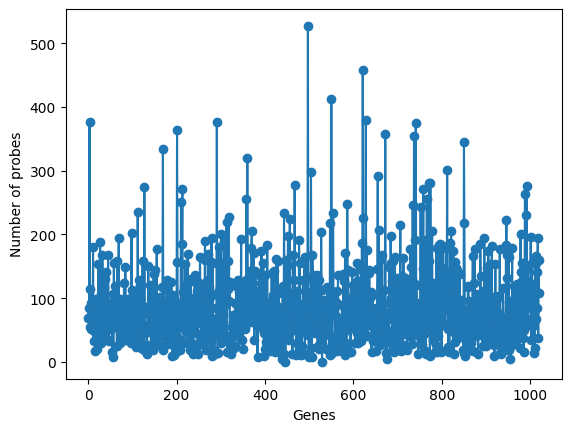

In [81]:
# this just checks the number of probes for each gene

import glob,os
import numpy as np
from tqdm.notebook import tqdm
fld_sv = r'probes'
in_files = glob.glob(fld_sv + r'/*_exons.fasta')
in_files = [fl for fl in in_files if 'auto' not in fl.lower()]

def read_probes(fl):
    pb_fl = fl.replace('.fasta','.csv')
    names,seqs = [],[]
    if os.path.exists(pb_fl):
        seqs,names = zip(*[ln.replace("b'",'').replace("'",'').split(',')[:2] for ln in open(pb_fl,'r')])
    return names,seqs
num_pbs = []
for fl in tqdm(in_files):
    names,seqs = read_probes(fl)
    num_pbs.append(len(names))
    
    
import matplotlib.pylab as plt
plt.figure()
plt.plot(num_pbs,'o-')
plt.ylabel('Number of probes')
plt.xlabel('Genes')

In [86]:
# this to make the current library compatible with other libraries by not using previously used barcodes

lib_fl = '/data/probe_libraries/CGBBL3_v2.fasta'
nms = [nm for nm in open(lib_fl,'r') if '>' in nm]
gns = list(np.unique([nm.split('__')[-1].split('_')[0] for nm in nms]))
bcms = list(np.unique([nm.split('__')[-2] for nm in nms]))

cdlib_fl = '/data/probe_libraries/DCBB_lib1_v3.fasta'
nms = [nm for nm in open(lib_fl,'r') if '>' in nm]
gns += list(np.unique([nm.split('__')[-1].split('_')[0] for nm in nms]))
bcms += list(np.unique([nm.split('__')[-2] for nm in nms]))

gns = np.unique(gns)
bcms = np.unique(bcms)


In [87]:
current_genes = [os.path.basename(ln).split('_')[0]for ln in in_files]
current_genes = [gn for gn in current_genes if gn not in gns]

In [88]:
len(current_genes)

587

In [62]:
# these are the primer sets

dic_pcr = {'W1A01': 'CGGCTCGCAGCGTGTAAACG', 'W1A02': 'TAATACGACTCACTATAGGGCATTTCAGGATCACCGGCGG', 
           'W1A03': 'CCCGCAATGGCTGACAACCG', 'W1A04': 'TAATACGACTCACTATAGGGCGTTGTATGCCCTCCACGC', 
           'W1A05': 'CATTCAGCATTGCGCAACGG', 'W1A06': 'TAATACGACTCACTATAGGGTCTTCCCGCAAATGCACCG', 
           'W1A07': 'CGCAAACTGGTGCGGAAGGC', 'W1A08': 'TAATACGACTCACTATAGGGCCCTTTCGCGCTGCATCGAC', 
           'W1A09': 'TTGTTGAGGCGGCGGAAGTC', 'W1A10': 'TAATACGACTCACTATAGGGATTGCCGCATGGTTTCCG', 
           'W1A11': 'TTGCTAGCGTGGGCCAATCG', 'W1A12': 'TAATACGACTCACTATAGGGCCATTGCCCGCGAGGTCGAG', 
           'W1B01': 'TTGGGCGTGCACGTCAATTC', 'W1B02': 'TAATACGACTCACTATAGGGCAATTAATCGCCCGGTGCCA', 
           'W1B03': 'GACATCCAGGCGCGGACAAC', 'W1B04': 'TAATACGACTCACTATAGGGCTTGTGCATCGCGCCAAAGA', 
           'W1B05': 'CGGGTTTCGTTGCGCACACC', 'W1B06': 'TAATACGACTCACTATAGGGCCTGTGCGGAAATCGCGAGA', 
           'W1B07': 'CACGTGGCCTCTCGCACATC', 'W1B08': 'TAATACGACTCACTATAGGGCATGTGTCACCGCTCCGTGG', 
           'W1B09': 'TAGGCGTGTCGGCCAACCAG', 'W1B10': 'TAATACGACTCACTATAGGGCGGGTCGATCATCGGCTTTG', 
           'W1B11': 'TTGGACCGAGCCAGTACCGC', 'W1B12': 'TAATACGACTCACTATAGGGCAGGTTGGCCGCGACTTCTG'}
dic_pcr_inv = {(dic_pcr[key] if len(dic_pcr[key])<=20 else lt.seqrc(dic_pcr[key][-20:])):key for key in dic_pcr}

In [89]:
# also have human readouts
seqs = dict(zip(*lt.fastaread('final_candidate_readouts_human.fasta')))
bcm_free_dic = {bcm:seqs[bcm] for bcm in seqs if bcm not in bcms}
#bcm_free_dic

In [90]:
current_genes = [os.path.basename(ln).split('_')[0]for ln in in_files]
keep_genes = [gn not in gns for gn in current_genes]

files_ = np.array(in_files)[keep_genes]
print(len(files_))

587


In [91]:
bcms_free = list(bcm_free_dic.keys())

In [92]:
# and this part makes the completed probes with the selected primer sets

lib_names = []
lib_seqs = []
#final_primers_used = []

def read_target_seqs(fl):
    txts = np.array([ln.replace('\n','').split(',') for ln in open(fl,'r') if len(ln)>2][1:])
    seqs = np.array([txt.replace("'",'')[1:] for txt in txts[:,0]])
    names = txts[:,1]
    return names,seqs

#get PCR primers
dic_pcr = {'W1A01': 'CGGCTCGCAGCGTGTAAACG', 'W1A02': 'TAATACGACTCACTATAGGGCATTTCAGGATCACCGGCGG', 'W1A03': 'CCCGCAATGGCTGACAACCG', 'W1A04': 'TAATACGACTCACTATAGGGCGTTGTATGCCCTCCACGC', 'W1A05': 'CATTCAGCATTGCGCAACGG', 'W1A06': 'TAATACGACTCACTATAGGGTCTTCCCGCAAATGCACCG', 'W1A07': 'CGCAAACTGGTGCGGAAGGC', 'W1A08': 'TAATACGACTCACTATAGGGCCCTTTCGCGCTGCATCGAC', 'W1A09': 'TTGTTGAGGCGGCGGAAGTC', 'W1A10': 'TAATACGACTCACTATAGGGATTGCCGCATGGTTTCCG', 'W1A11': 'TTGCTAGCGTGGGCCAATCG', 'W1A12': 'TAATACGACTCACTATAGGGCCATTGCCCGCGAGGTCGAG', 'W1B01': 'TTGGGCGTGCACGTCAATTC', 'W1B02': 'TAATACGACTCACTATAGGGCAATTAATCGCCCGGTGCCA', 'W1B03': 'GACATCCAGGCGCGGACAAC', 'W1B04': 'TAATACGACTCACTATAGGGCTTGTGCATCGCGCCAAAGA', 'W1B05': 'CGGGTTTCGTTGCGCACACC', 'W1B06': 'TAATACGACTCACTATAGGGCCTGTGCGGAAATCGCGAGA', 'W1B07': 'CACGTGGCCTCTCGCACATC', 'W1B08': 'TAATACGACTCACTATAGGGCATGTGTCACCGCTCCGTGG', 'W1B09': 'TAGGCGTGTCGGCCAACCAG', 'W1B10': 'TAATACGACTCACTATAGGGCGGGTCGATCATCGGCTTTG', 'W1B11': 'TTGGACCGAGCCAGTACCGC', 'W1B12': 'TAATACGACTCACTATAGGGCAGGTTGGCCGCGACTTCTG'}

primerAnm1 = 'W1A07'
primerBnm1 = 'W1A04'
# put your own name here, BMBBL is this particular library
tag_lib1 = 'BMBBL1__'+primerAnm1+'__'+primerBnm1
primerA1 = dic_pcr[primerAnm1]
primerB1 = str(dic_pcr[primerBnm1])
primerB1 = lt.seqrc(primerB1[-20:])


ifl = 0
for fl in files_:
    fl = fl.replace('.fasta','.csv')
    if os.path.exists(fl):
        names,seqs = read_target_seqs(fl)
        if True:
            if len(seqs)>5:
                names = names[:60]
                seqs = seqs[:60]
                gn_name = names[0].split('_pb_')[0].split('_exons')[0]
    
    
                ndb_nms = [bcms_free[ifl]]
                ndb_sqs = [bcm_free_dic[nmR]for nmR in ndb_nms]
    
    
                primerAnm,primerA,primerBnm,primerB,tag_lib = primerAnm1,primerA1,primerBnm1,primerB1,tag_lib1
    
                for isq,(nm,sq) in enumerate(zip(names,seqs)):
                    ndb_sq = ndb_sqs[isq%len(ndb_sqs)]
                    ndb_nm = ndb_nms[isq%len(ndb_nms)]
                    tag = tag_lib+'__'+ndb_nm+'__'
                    sq_ = lt.up_down([primerA,ndb_sq,lt.seqrc(sq),ndb_sq,ndb_sq,primerB])
                    nm_ = tag+nm
                    lib_names.append(nm_)
                    lib_seqs.append(sq_)
                ifl+=1
                


In [93]:
len(lib_seqs)

29546

In [94]:
# and write it with your own name
lt.fastawrite('BMBBL1v2.fasta',lib_names,lib_seqs)

In [ ]:
# at this point do some sanity checks, open the above file and copy the unique target sequence for a probe and BLASTN it to make sure
# it hits to the proper gene and only to that gene.  Repeat it for a bunch of random other genes/probes

In [95]:
print(len(lib_names),np.unique([len(sq)for sq in lib_seqs]))
print(lib_names[0])

29546 [140]
BMBBL1__W1A07__W1A04__bcm_15521__Cd4_exons_pb_0


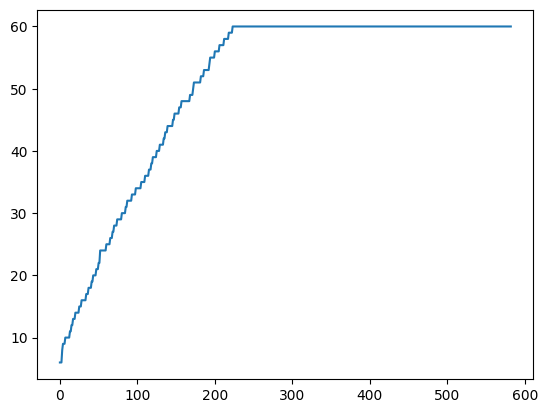

In [96]:
gns_lib,cts_lib = np.unique([nm.split('__')[-1].split('_')[0] for nm in lib_names],return_counts=True)
len(gns_lib)
plt.plot(np.sort(cts_lib))

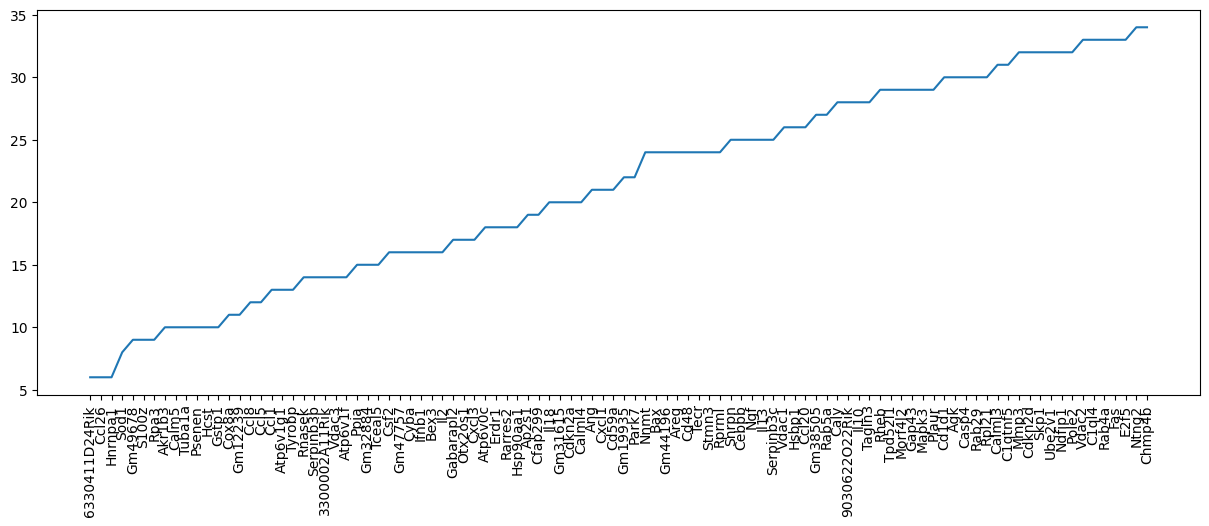

In [97]:
plt.figure(figsize=(15,5))
x = np.sort(cts_lib)[:100]
gns_lib_ = gns_lib[np.argsort(cts_lib)]
plt.plot(x)
plt.xticks(np.arange(len(x)),gns_lib_[:len(x)],rotation='vertical');

In [99]:
# this is a sanity check 
len(np.unique([sq[20:40] for sq in lib_seqs]))

583

In [100]:
lib_names[15000],lib_seqs[15000]

('BMBBL1__W1A07__W1A04__bcm_18764__Icam1_exons_pb_1386',
 'CGCAAACTGGTGCGGAAGGCtctaacggttaggcggagtaTATGTACCATTCATCTCCTGTTTGACAGACTTCACCACCCtctaacggttaggcggagtaTCTAACGGTTAGGCGGAGTAgcgtggagggcatacaacgc')

Text(0.5, 0, 'readouts')

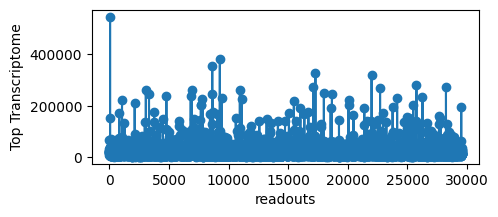

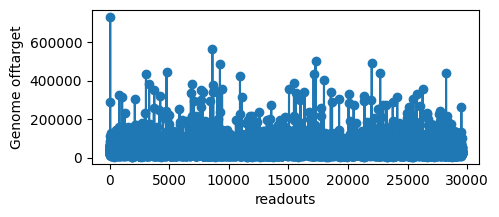

In [101]:
# this part shows the number of off targets at the 12bp threshold

genome_fl = '/data/mm10/allgenome_12w.bin'

ct_gn = ld.countTable(word=12,save_file=genome_fl.replace('.fasta','_12w.bin').replace('.fna','_12w.bin'),
                   sparse=False)
ct_gn.load()

tr_fl = r'/data/mm10_transcriptome/mouse_GRCm39_genesUnspliced_12w.bin'
ct_tr = ld.countTable(word=12,save_file=tr_fl.replace('.fasta','_12w.bin').replace('.fna','_12w.bin'),
                   sparse=False)
ct_tr.load()

offts = np.array([[ct.get(R)+ct.get(lt.seqrc(R)) for R in lib_seqs] for ct in [ct_tr,ct_gn]]).T

#print(np.any(offts>np.median(offts)*5))
import matplotlib.pylab as plt
plt.figure(figsize=(5,2))
plt.plot(offts[:,0],'o-')
plt.ylabel('Top Transcriptome')
plt.xlabel('readouts')
plt.figure(figsize=(5,2))
plt.plot(offts[:,1],'o-')
plt.ylabel('Genome offtarget')
plt.xlabel('readouts')

Text(0.5, 0, 'readouts')

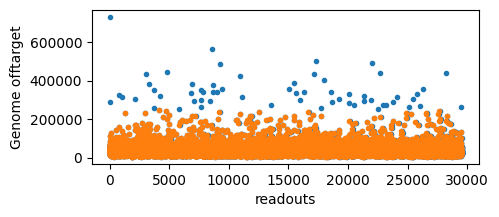

In [102]:
# this part removes the probes that have too many off target 12bp matches

keep = offts[:,1]<250000


plt.figure(figsize=(5,2))
plt.plot(offts[:,1],'.')
plt.plot(offts[keep,1],'.')
plt.ylabel('Genome offtarget')
plt.xlabel('readouts')

In [103]:
# write your final library file
lt.fastawrite('BMBBL1_v3.fasta',np.array(lib_names)[keep],np.array(lib_seqs)[keep])